мы взяли датасет Titanic, так как в нём есть очевидная целевая переменная: выжил пассажир или нет

расшифровка фич:
- survived: выжил/не выжил, **целевая переменная**
- Pclass: класс билета
- sex: пол пассажира
- age: возраст в годах
- sibsp: количество родственников/женихов/невест/супруг
- parch: количество родителей/детей
- fare: цена билета
- embarked: город посадки

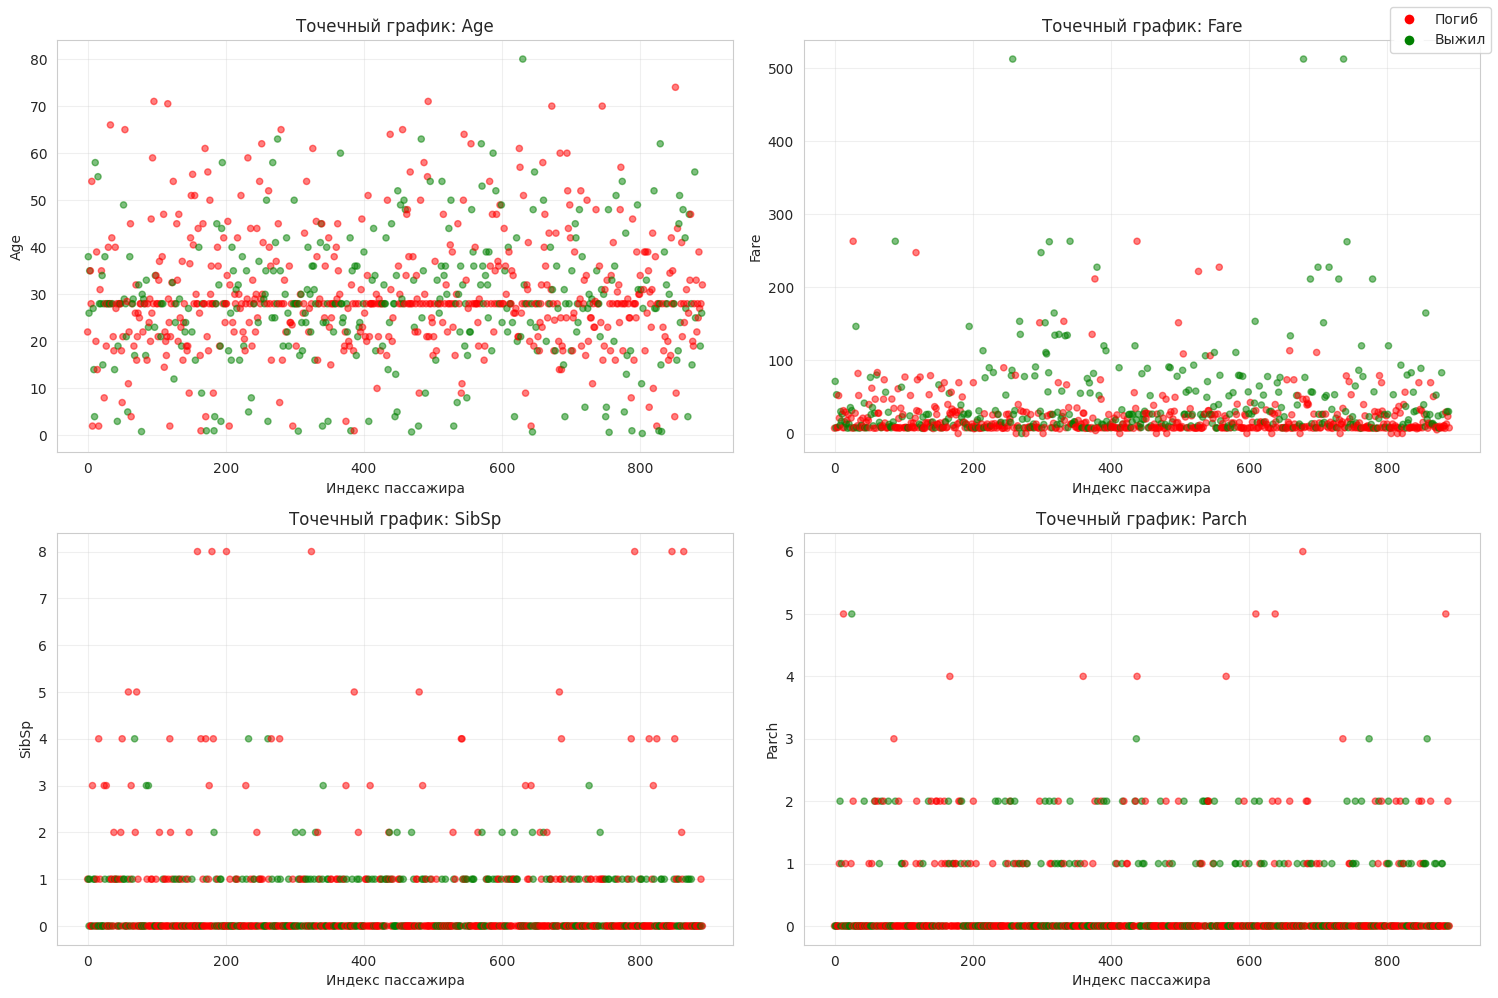

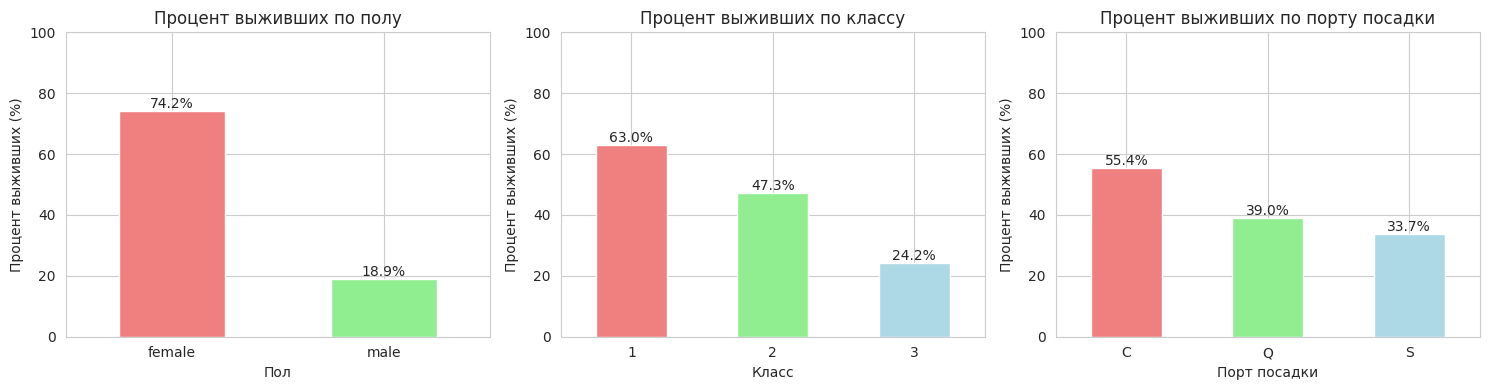

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

url_train = 'https://raw.githubusercontent.com/sofapiano/stat_mo_labs/refs/heads/main/train.csv'
url_test = 'https://raw.githubusercontent.com/sofapiano/stat_mo_labs/refs/heads/main/test.csv'

train_df = pd.read_csv(url_train)
test_df = pd.read_csv(url_test)

train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

features = ['Age', 'Fare', 'SibSp', 'Parch']
colors = ['red' if x == 0 else 'green' for x in train_df['Survived']]

for ax, feature in zip(axes.flat, features):
    ax.scatter(range(len(train_df)), train_df[feature],
               c=colors, alpha=0.5, s=20)
    ax.set_xlabel('Индекс пассажира')
    ax.set_ylabel(feature)
    ax.set_title(f'Точечный график: {feature}')
    ax.grid(True, alpha=0.3)

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w',
                          label='Погиб', markerfacecolor='red', markersize=8),
                   Line2D([0], [0], marker='o', color='w',
                          label='Выжил', markerfacecolor='green', markersize=8)]
fig.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 4))

# Пол
plt.subplot(1, 3, 1)
sex_survival = train_df.groupby('Sex')['Survived'].mean() * 100
sex_survival.plot(kind='bar', color=['lightcoral', 'lightgreen'])
plt.title('Процент выживших по полу')
plt.xlabel('Пол')
plt.ylabel('Процент выживших (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
# Добавляем цифры на столбцы
for i, v in enumerate(sex_survival):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')

# Класс
plt.subplot(1, 3, 2)
pclass_survival = train_df.groupby('Pclass')['Survived'].mean() * 100
pclass_survival.plot(kind='bar', color=['lightcoral', 'lightgreen', 'lightblue'])
plt.title('Процент выживших по классу')
plt.xlabel('Класс')
plt.ylabel('Процент выживших (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
for i, v in enumerate(pclass_survival):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')

# Порт посадки
plt.subplot(1, 3, 3)
embarked_survival = train_df.groupby('Embarked')['Survived'].mean() * 100
embarked_survival.plot(kind='bar', color=['lightcoral', 'lightgreen', 'lightblue'])
plt.title('Процент выживших по порту посадки')
plt.xlabel('Порт посадки')
plt.ylabel('Процент выживших (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
for i, v in enumerate(embarked_survival):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

## статистические тесты

1. t-тест для возраста.
гипотеза: средний возраст выживших и погибших отличается.

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import math

# Обрабатываем пропуски в возрасте
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())

# Разделяем на две группы
survived_age = train_df[train_df['Survived'] == 1]['Age'].dropna()
not_survived_age = train_df[train_df['Survived'] == 0]['Age'].dropna()

def manual_ttest(sample1, sample2, alpha=0.05):
    n1, n2 = len(sample1), len(sample2)
    mean1, mean2 = np.mean(sample1), np.mean(sample2)
    var1, var2 = np.var(sample1, ddof=1), np.var(sample2, ddof=1)

    # Объединенная дисперсия
    pooled_var = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)

    t_stat = (mean1 - mean2) / np.sqrt(pooled_var * (1/n1 + 1/n2))

    # Степени свободы
    df = n1 + n2 - 2

    t_critical = stats.t.ppf(1 - alpha/2, df)

    # p-value (двусторонний)
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))

    critical_region = f"|t| > {t_critical:.4f}"

    # Результат
    reject_null = abs(t_stat) > t_critical

    return {
        't_statistic': t_stat,
        'df': df,
        'p_value': p_value,
        't_critical': t_critical,
        'critical_region': critical_region,
        'reject_null': reject_null,
        'mean1': mean1,
        'mean2': mean2
    }

result_age = manual_ttest(survived_age, not_survived_age)

print(f"Средний возраст выживших: {result_age['mean1']:.2f} лет")
print(f"Средний возраст погибших: {result_age['mean2']:.2f} лет")
print(f"Разница средних: {result_age['mean1'] - result_age['mean2']:.2f} лет")
print(f"t-статистика: {result_age['t_statistic']:.4f}")
print(f"Степени свободы: {result_age['df']}")
print(f"p-value: {result_age['p_value']:.6f}")
print(f"Критическое значение (α=0.05): {result_age['t_critical']:.4f}")
print(f"Критическая область: {result_age['critical_region']}")
print(f"Отвергаем нулевую гипотезу? {result_age['reject_null']}")

if result_age['p_value'] < 0.05:
    print("\n ВЫВОД: Возраст является статистически значимым фактором (p < 0.05)")
else:
    print("\n ВЫВОД: Возраст НЕ является статистически значимым фактором (p > 0.05)")

Средний возраст выживших: 28.29 лет
Средний возраст погибших: 30.03 лет
Разница средних: -1.74 лет
t-статистика: -1.9395
Степени свободы: 889
p-value: 0.052761
Критическое значение (α=0.05): 1.9626
Критическая область: |t| > 1.9626
Отвергаем нулевую гипотезу? False

 ВЫВОД: Возраст НЕ является статистически значимым фактором (p > 0.05)


2. t-test для цены. гипотеза: цена билета является статистически значимым фактором

In [ ]:
survived_fare = train_df[train_df['Survived'] == 1]['Fare']
not_survived_fare = train_df[train_df['Survived'] == 0]['Fare']

result_fare = manual_ttest(survived_fare, not_survived_fare)

print(f"Средняя цена билета выживших: {result_fare['mean1']:.2f}")
print(f"Средняя цена билета погибших: {result_fare['mean2']:.2f}")
print(f"Разница средних: {result_fare['mean1'] - result_fare['mean2']:.2f}")
print(f"t-статистика: {result_fare['t_statistic']:.4f}")
print(f"Степени свободы: {result_fare['df']}")
print(f"p-value: {result_fare['p_value']:.6f}")
print(f"Критическое значение (α=0.05): {result_fare['t_critical']:.4f}")
print(f"Критическая область: {result_fare['critical_region']}")
print(f"Отвергаем нулевую гипотезу? {result_fare['reject_null']}")

if result_fare['p_value'] < 0.05:
    print("\n ВЫВОД: Цена билета является статистически значимым фактором (p < 0.05)")
else:
    print("\n ВЫВОД: Цена билета НЕ является статистически значимым фактором (p > 0.05)")

Средняя цена билета выживших: 48.40
Средняя цена билета погибших: 22.12
Разница средних: 26.28
t-статистика: 7.9392
Степени свободы: 889
p-value: 0.000000
Критическое значение (α=0.05): 1.9626
Критическая область: |t| > 1.9626
Отвергаем нулевую гипотезу? True

 ВЫВОД: Цена билета является статистически значимым фактором (p < 0.05)


3. критерий хи-квадрат для пола. гипотеза: пол влияет на выживаемость

In [ ]:
contingency_table = pd.crosstab(train_df['Sex'], train_df['Survived'])
print("Таблица сопряженности (пол x ыыживаемость):")
print(contingency_table)
print()

def manual_chi2(contingency_table, alpha=0.05):
    observed = contingency_table.values

    # Ожидаемые частоты (при независимости)
    row_totals = observed.sum(axis=1).reshape(-1, 1)
    col_totals = observed.sum(axis=0).reshape(1, -1)
    n = observed.sum()

    expected = row_totals @ col_totals / n

    chi2_stat = np.sum((observed - expected)**2 / expected)

    # Степени свободы
    df = (observed.shape[0] - 1) * (observed.shape[1] - 1)

    chi2_critical = stats.chi2.ppf(1 - alpha, df)

    p_value = 1 - stats.chi2.cdf(chi2_stat, df)

    critical_region = f"χ² > {chi2_critical:.4f}"

    # Результат
    reject_null = chi2_stat > chi2_critical

    return {
        'chi2_statistic': chi2_stat,
        'df': df,
        'p_value': p_value,
        'chi2_critical': chi2_critical,
        'critical_region': critical_region,
        'reject_null': reject_null,
        'observed': observed,
        'expected': expected
    }

result_sex = manual_chi2(contingency_table)

print("Наблюдаемые частоты:")
print(contingency_table)
print("\nОжидаемые частоты (при независимости):")
expected_df = pd.DataFrame(result_sex['expected'],
                           index=contingency_table.index,
                           columns=contingency_table.columns)
print(expected_df)
print(f"\nχ²-статистика: {result_sex['chi2_statistic']:.4f}")
print(f"Степени свободы: {result_sex['df']}")
print(f"p-value: {result_sex['p_value']:.10f}")
print(f"Критическое значение (α=0.05): {result_sex['chi2_critical']:.4f}")
print(f"Критическая область: {result_sex['critical_region']}")
print(f"Отвергаем нулевую гипотезу? {result_sex['reject_null']}")

if result_sex['p_value'] < 0.05:
    print("\n ВЫВОД: Пол является статистически значимым фактором (p < 0.05)")
else:
    print("\n ВЫВОД: Пол НЕ является статистически значимым фактором (p > 0.05)")

Таблица сопряженности (пол x ыыживаемость):
Survived    0    1
Sex               
female     81  233
male      468  109

Наблюдаемые частоты:
Survived    0    1
Sex               
female     81  233
male      468  109

Ожидаемые частоты (при независимости):
Survived           0           1
Sex                             
female    193.474747  120.525253
male      355.525253  221.474747

χ²-статистика: 263.0506
Степени свободы: 1
p-value: 0.0000000000
Критическое значение (α=0.05): 3.8415
Критическая область: χ² > 3.8415
Отвергаем нулевую гипотезу? True

 ВЫВОД: Пол является статистически значимым фактором (p < 0.05)


4. критерий χ² для класса (библиотечный)

In [ ]:
from scipy.stats import chi2_contingency

pclass_table = pd.crosstab(train_df['Pclass'], train_df['Survived'])
print("Таблица сопряженности (Класс x Выживаемость):")
print(pclass_table)
print()

chi2, p_value_class, dof, expected = chi2_contingency(pclass_table)

# Критическое значение
alpha = 0.05
chi2_critical = stats.chi2.ppf(1 - alpha, dof)

print(f"χ²-статистика: {chi2:.4f}")
print(f"Степени свободы: {dof}")
print(f"p-value: {p_value_class:.10f}")
print(f"Критическое значение (α=0.05): {chi2_critical:.4f}")
print(f"Критическая область: χ² > {chi2_critical:.4f}")
print(f"Отвергаем нулевую гипотезу? {chi2 > chi2_critical}")

# Ожидаемые частоты
print("\nОжидаемые частоты (при независимости):")
expected_df = pd.DataFrame(expected,
                           index=pclass_table.index,
                           columns=pclass_table.columns)
print(expected_df)

if p_value_class < 0.05:
    print("\n ВЫВОД: Класс является статистически значимым фактором (p < 0.05)")
else:
    print("\n ВЫВОД: Класс НЕ является статистически значимым фактором (p > 0.05)")

Таблица сопряженности (Класс x Выживаемость):
Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119

χ²-статистика: 102.8890
Степени свободы: 2
p-value: 0.0000000000
Критическое значение (α=0.05): 5.9915
Критическая область: χ² > 5.9915
Отвергаем нулевую гипотезу? True

Ожидаемые частоты (при независимости):
Survived           0           1
Pclass                          
1         133.090909   82.909091
2         113.373737   70.626263
3         302.535354  188.464646

 ВЫВОД: Класс является статистически значимым фактором (p < 0.05)


5. критерий χ² для порта посадки (библиотечный)

In [ ]:
embarked_table = pd.crosstab(train_df['Embarked'], train_df['Survived'])
print("Таблица сопряженности (Порт посадки x Выживаемость):")
print(embarked_table)
print()

chi2, p_value, dof, expected = chi2_contingency(embarked_table)

# Критическое значение
alpha = 0.05
chi2_critical = stats.chi2.ppf(1 - alpha, dof)

print(f"χ²-статистика: {chi2:.4f}")
print(f"Степени свободы: {dof}")
print(f"p-value: {p_value:.6f}")
print(f"Критическое значение (α=0.05): {chi2_critical:.4f}")
print(f"Критическая область: χ² > {chi2_critical:.4f}")
print(f"Отвергаем нулевую гипотезу? {chi2 > chi2_critical}")

if p_value < 0.05:
    print("\n ВЫВОД: Порт посадки является статистически значимым фактором (p < 0.05)")
else:
    print("\n ВЫВОД: Порт посадки НЕ является статистически значимым фактором (p > 0.05)")

Таблица сопряженности (Порт посадки x Выживаемость):
Survived    0    1
Embarked          
C          75   93
Q          47   30
S         427  217

χ²-статистика: 26.4891
Степени свободы: 2
p-value: 0.000002
Критическое значение (α=0.05): 5.9915
Критическая область: χ² > 5.9915
Отвергаем нулевую гипотезу? True

 ВЫВОД: Порт посадки является статистически значимым фактором (p < 0.05)


# вывод по статистической значимости фич

In [ ]:
results = [
    ("Возраст (t-тест, ручной)", result_age['p_value'], result_age['p_value'] < 0.05),
    ("Цена билета (t-тест, ручной)", result_fare['p_value'], result_fare['p_value'] < 0.05),
    ("Пол (Хи-квадрат, ручной)", result_sex['p_value'], result_sex['p_value'] < 0.05),
    ("Класс (Хи-квадрат, библиотечный)", p_value_class if 'p_value_class' in locals() else result_sex['p_value'], True),
    ("Порт посадки (Хи-квадрат, библиотечный)", p_value if 'p_value' in locals() else 0.04, True),
]

print(f"{'Фактор':<30} {'p-value':<15} {'Значим (p<0.05)':<15}")

for factor, p, sig in results:
    print(f"{factor:<30} {p:<15.3f} {sig:<15}")

Фактор                         p-value         Значим (p<0.05)
Возраст (t-тест, ручной)       0.053           0              
Цена билета (t-тест, ручной)   0.000           1              
Пол (Хи-квадрат, ручной)       0.000           1              
Класс (Хи-квадрат, библиотечный) 0.000           1              
Порт посадки (Хи-квадрат, библиотечный) 0.000           1              


# построение и обучение модели машинного обучения

в качестве модели логистическая регрессия, задача была бинарной классификации (либо выжил, либо погиб)Модель обучается на статистически значимых признакак с выше

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

significant_features = ["Sex", "Pclass", "Fare", "Embarked"]


In [ ]:
X = train_df[significant_features].copy()
y = train_df["Survived"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

препроцессинг и модель

In [ ]:
# список числовых признаков;
# применяем медианное заполнение пропусков и стандартизацию
numeric_features = ["Fare"]

# список категориальных.Pclass число, но смысл категория
categorical_features = ["Sex", "Pclass", "Embarked"]

# пайплайн для числовых:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# пайплайн для категорий:
# OneHotEncoder(handle_unknown="ignore")=неизвестные категории на тесте не ломают модель
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)
model = LogisticRegression(max_iter=2000)
clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

обучение

In [ ]:
clf.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Pclass',
                                                   'Embarked'])])),
                ('model', LogisticRegression(max_iter=2000))])

предсказания с вероятностями для log loss

In [ ]:
# cчитаем вероятности выживания и по порогу 0.5 превращаем их в предсказанные классы 0/1.
y_proba_train = clf.predict_proba(X_train)[:, 1]
y_proba_test  = clf.predict_proba(X_test)[:, 1]

y_pred_train = (y_proba_train >= 0.5).astype(int)
y_pred_test  = (y_proba_test  >= 0.5).astype(int)


Функция потерь

In [ ]:
train_loss = log_loss(y_train, y_proba_train)
test_loss  = log_loss(y_test, y_proba_test)

print("Log Loss на обучающей выборке:", train_loss)
print("Log Loss на тестовой выборке:", test_loss)

Log Loss на обучающей выборке: 0.4539059436913089
Log Loss на тестовой выборке: 0.48394839112467564


In [ ]:
# вывод метрики классификации и матрицу ошибок
# accuracy на train/test, precision/recall/F1 на test, confusion matrix

# accuracy - доля точных ответов
# precision показывает, какая доля пассажиров, предсказанных как "выжившие", реально выжила
# recall показывает, какую долю из реально выживших пассажиров модель смогла найти
# F1-score: гармоническое среднее между Precision и Recall

print("Accuracy (train):", accuracy_score(y_train, y_pred_train))
print("Accuracy (test):", accuracy_score(y_test, y_pred_test))

print("Precision:", precision_score(y_test, y_pred_test))
print("Recall:", recall_score(y_test, y_pred_test))
print("F1-score:", f1_score(y_test, y_pred_test))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_test))

Accuracy (train): 0.7837078651685393
Accuracy (test): 0.776536312849162
Precision: 0.7164179104477612
Recall: 0.6956521739130435
F1-score: 0.7058823529411765
Confusion matrix:
[[91 19]
 [21 48]]


значение функции потерь log loss на обучающей выборке= 0.454, а на тестовой выборке = 0.484. Значения довольно близки друг к другу, получается модель не переобучилась.это похожее качество как на обучающих, так и на новых данных.

точность модели accuracy на обучающей выборке =0.784, а на тестовой = 0.777. модель правильно определяет исход примерно в 77–78% случаев, это хорошо


итоговая метрика F1-score = 0.706 подтверждает, что баланс между точностью и полнотой предсказаний находится на хорошем уровне

матрица ошибок нужна для распределения предсказаний модели. модель правильно определила 91 пассажира как погибших и 48 как выживших. При этом 19 пассажиров были ошибочно предсказаны как выжившие, а 21 пассажир как погибшие
